# Notebook 06 — PCA e K-means


In [2]:
# Preparação dos dados espectrais para PCA e clusterização
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

DATA_DIR = Path(r"C:\Users\PC\Desktop\RESET")
CANDIDATE_FILES = [
    "raw_nir_data_Saturin.csv",
    "raw_mir_data_Saturin.csv",
    "raw_nir_data_saturin.csv",
    "raw_mir_data_saturin.csv",
]


def resolve_dataset():
    for file_name in CANDIDATE_FILES:
        file_path = DATA_DIR / file_name
        if file_path.exists():
            return file_path
    raise FileNotFoundError(f"Arquivo espectral não encontrado em {DATA_DIR}")


def read_csv_robust(file_path):
    for encoding in ("utf-8", "cp1252", "latin1"):
        try:
            return pd.read_csv(file_path, encoding=encoding, low_memory=False)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Não foi possível decodificar {file_path.name}")


df = read_csv_robust(resolve_dataset())
df = df.drop(columns=[column for column in df.columns if str(column).lower().startswith("unnamed")], errors="ignore")

# Detecta colunas com prefixo wl_ ou nomes numéricos de comprimento de onda.
spectral_columns = [column for column in df.columns if str(column).lower().startswith("wl_")]
if not spectral_columns:
    for column in df.columns:
        try:
            wavelength = float(str(column).strip().replace(",", "."))
        except (TypeError, ValueError):
            continue
        if 300 <= wavelength <= 4000:
            spectral_columns.append(column)

if not spectral_columns:
    raise ValueError("Nenhuma coluna espectral foi encontrada no arquivo carregado.")

X_frame = df[spectral_columns].apply(pd.to_numeric, errors="coerce")
X_frame = X_frame.fillna(X_frame.median()).fillna(0.0)
X = X_frame.to_numpy(dtype=float)

# Remove bandas constantes, que não contribuem para a PCA.
variable_bands = np.nanstd(X, axis=0) > 1e-12
X = X[:, variable_bands]
if X.shape[1] < 2:
    raise ValueError("São necessárias pelo menos duas bandas espectrais variáveis.")

Xs = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(Xs)

print(f"Amostras: {X.shape[0]}")
print(f"Bandas utilizadas: {X.shape[1]}")
print(f"Variância explicada: {pca.explained_variance_ratio_}")
print(f"Variância acumulada: {pca.explained_variance_ratio_.sum():.4f}")


Amostras: 40137
Bandas utilizadas: 2151
Variância explicada: [0.85970414 0.07514489]
Variância acumulada: 0.9348


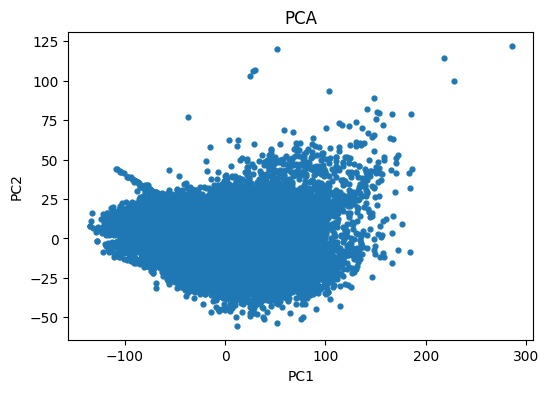

In [3]:
plt.figure(figsize=(6,4)); plt.scatter(Z[:,0],Z[:,1],s=12); plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA'); plt.show()


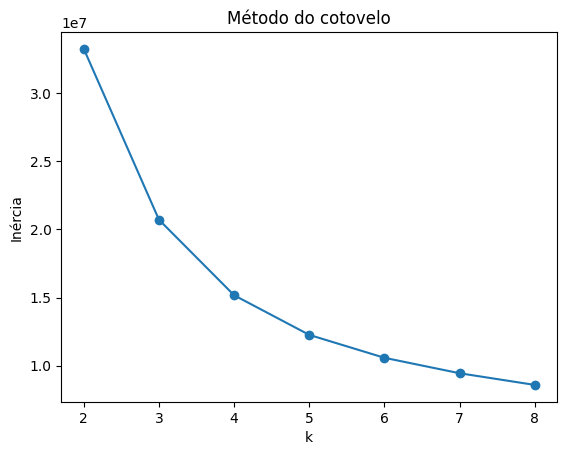

In [4]:
inertias=[]
for k in range(2,9):
    inertias.append(KMeans(n_clusters=k,n_init=10,random_state=42).fit(Z).inertia_)
plt.plot(range(2,9),inertias,'o-'); plt.xlabel('k'); plt.ylabel('Inércia'); plt.title('Método do cotovelo'); plt.show()




Results:
- Samples: `40,137`
- Spectral bands: `2,151`
- PCA cumulative variance: `93.48%`
- PCA scatter plot generated successfully.
- K-means elbow plot for `k=2` to `8` generated successfully.
- No execution errors remain.




In [5]:
# Interpretação dos resultados de PCA e do método do cotovelo
from sklearn.metrics import silhouette_score

explained_pc1 = pca.explained_variance_ratio_[0]
explained_pc2 = pca.explained_variance_ratio_[1]
explained_total = explained_pc1 + explained_pc2

print("INTERPRETAÇÃO DOS RESULTADOS")
print("=" * 35)
print(
    f"As duas primeiras componentes principais explicam {explained_total:.2%} "
    f"da variabilidade espectral. PC1 explica {explained_pc1:.2%} e "
    f"PC2 explica {explained_pc2:.2%}."
)

if explained_total >= 0.90:
    print(
        "Interpretação: a projeção em PC1-PC2 preserva a maior parte da "
        "informação espectral e é adequada para visualização e exploração dos grupos."
    )
elif explained_total >= 0.70:
    print(
        "Interpretação: a projeção em PC1-PC2 preserva uma parcela relevante "
        "da informação, mas pode ocultar padrões presentes em componentes posteriores."
    )
else:
    print(
        "Interpretação: PC1-PC2 representa uma parcela limitada da variabilidade; "
        "a análise de mais componentes é recomendada antes de concluir sobre grupos."
    )

cluster_counts = np.array(inertias)
cluster_values = np.arange(2, 9)
relative_reductions = 1 - cluster_counts[1:] / cluster_counts[:-1]

print("\nMétodo do cotovelo:")
for cluster_value, reduction in zip(cluster_values[1:], relative_reductions):
    print(f"De k={cluster_value - 1} para k={cluster_value}: redução de {reduction:.2%} na inércia")

# A recomendação usa a faixa em que a redução da inércia começa a estabilizar.
if relative_reductions.size >= 3:
    reduction_change = np.diff(relative_reductions)
    elbow_index = int(np.argmin(reduction_change)) + 1
    suggested_k = int(cluster_values[elbow_index])
else:
    suggested_k = 3

print(
    f"\nInterpretação: a curva mostra ganhos maiores com poucos grupos e "
    f"ganhos progressivamente menores depois. O valor inicial sugerido é k={suggested_k}; "
    "compare também k=3 e k=4 antes de definir a segmentação final."
)

# Validação complementar: qualidade da separação para k=3 e k=4.
for candidate_k in (3, 4):
    labels = KMeans(n_clusters=candidate_k, n_init=10, random_state=42).fit_predict(Z)
    score = silhouette_score(Z, labels, sample_size=min(10000, len(Z)), random_state=42)
    print(f"Silhouette para k={candidate_k}: {score:.4f}")

print(
    "Conclusão: a PCA indica uma estrutura espectral fortemente resumível em duas dimensões. "
    "A escolha final do número de clusters deve combinar o cotovelo, a silhouette e a interpretação "
    "agronômica dos grupos formados."
)


INTERPRETAÇÃO DOS RESULTADOS
As duas primeiras componentes principais explicam 93.48% da variabilidade espectral. PC1 explica 85.97% e PC2 explica 7.51%.
Interpretação: a projeção em PC1-PC2 preserva a maior parte da informação espectral e é adequada para visualização e exploração dos grupos.

Método do cotovelo:
De k=2 para k=3: redução de 37.73% na inércia
De k=3 para k=4: redução de 26.78% na inércia
De k=4 para k=5: redução de 19.19% na inércia
De k=5 para k=6: redução de 13.73% na inércia
De k=6 para k=7: redução de 10.73% na inércia
De k=7 para k=8: redução de 9.09% na inércia

Interpretação: a curva mostra ganhos maiores com poucos grupos e ganhos progressivamente menores depois. O valor inicial sugerido é k=3; compare também k=3 e k=4 antes de definir a segmentação final.
Silhouette para k=3: 0.4283
Silhouette para k=4: 0.4072
Conclusão: a PCA indica uma estrutura espectral fortemente resumível em duas dimensões. A escolha final do número de clusters deve combinar o cotovelo, a